## ChatGPT Word Count+Phrase Analysis Notebook

This notebook uses the data from the count_chat_words.py script, and cannot be run without it. 

### 1. Importing Data 

Import the csv file that was saved at the end of the aforementioned script.

NB: If you are using an environment, please remember to choose kernel accordingly


In [27]:
# Import libraries
import spacy
from collections import Counter
import pandas as pd
import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, levene
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
import os
from statsmodels.stats.proportion import proportions_ztest


# Import CSV file
df= pd.read_csv("df_desc_with_chatgpt_counts.csv")
df_filtered = df.dropna(subset=["group", "chatgpt_word_ratio", "chatgpt_word_count"])

df_filtered = df_filtered[df_filtered["chatgpt_word_ratio"] > 0]

## Log transform (if needed)

# Create a new column with the log-transformed values
df_filtered["log_chatgpt_ratio"] = np.log1p(df_filtered["chatgpt_word_ratio"])



### ChatGPT Word & Phrase Ratio Analysis

To unequal groups, the ratio is used rather than the raw count of ChatGPT words and phrases. This Ratio was calculated in the previous script. 

            count      mean       std       min       25%       50%       75%  \
group                                                                           
2022       5069.0  3.309634  2.168602  0.576369  1.886792  2.710027  4.000000   
2024/2025  4133.0  3.159464  2.057859  0.670241  1.801802  2.597403  4.016064   

                max  
group                
2022       40.00000  
2024/2025  29.70297  


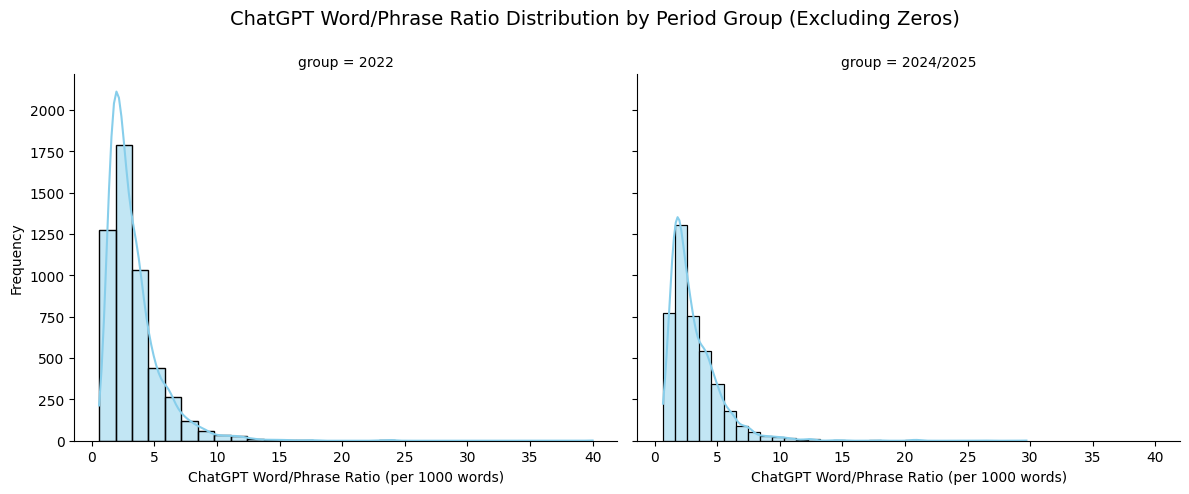

Plot saved to 'plot_outputs/chat_word_ratio_distribution_by_period_group_nonzero.png'
            count      mean       std       min       25%       50%       75%  \
group                                                                           
2022       5069.0  1.370141  0.404304  0.455124  1.060146  1.311039  1.609438   
2024/2025  4133.0  1.336500  0.401340  0.512968  1.030263  1.280212  1.612646   

                max  
group                
2022       3.713572  
2024/2025  3.424359  


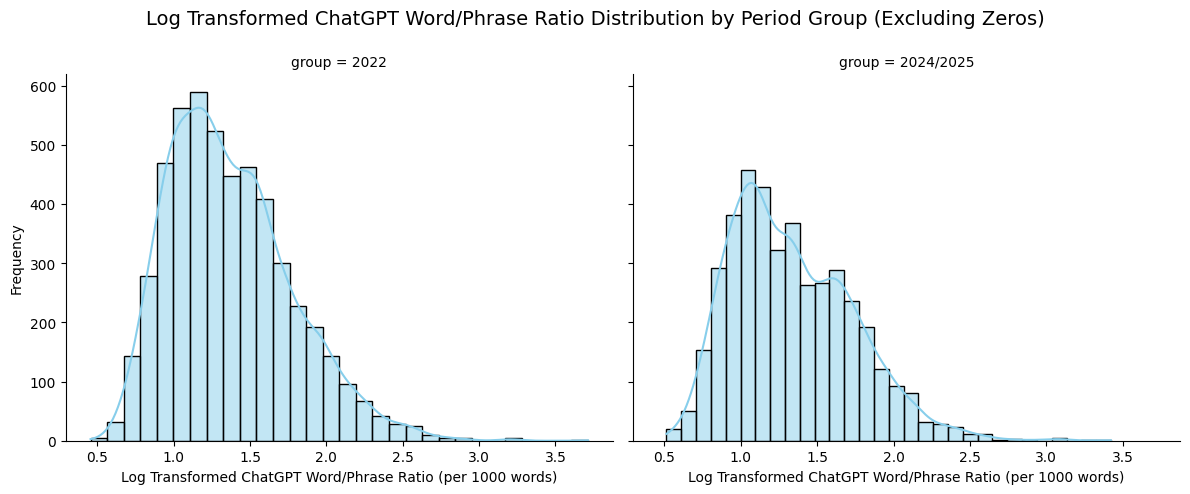

Plot saved to 'plot_outputs/log_chat_word_ratio_distribution_by_period_group_nonzero.png'


In [28]:
# Create output directory for consistency
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Summary statistics (excl. 0's)
print(df_filtered.groupby("group")["chatgpt_word_ratio"].describe())


# Faceted histogram EXCLUDING zeros
g = sns.FacetGrid(
    df_filtered,
    col="group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "chatgpt_word_ratio", bins=30, kde=True, color="skyblue")
g.set_axis_labels("ChatGPT Word/Phrase Ratio (per 1000 words)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("ChatGPT Word/Phrase Ratio Distribution by Period Group (Excluding Zeros)", fontsize=14)

# Save plot
output_path = os.path.join(output_plot_dir, "chat_word_ratio_distribution_by_period_group_nonzero.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")

## Same but with Log
# Create output directory for consistency
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Summary statistics (excl. 0's)
print(df_filtered.groupby("group")["log_chatgpt_ratio"].describe())


# Faceted histogram EXCLUDING zeros
g = sns.FacetGrid(
    df_filtered,
    col="group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "log_chatgpt_ratio", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Log Transformed ChatGPT Word/Phrase Ratio (per 1000 words)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Log Transformed ChatGPT Word/Phrase Ratio Distribution by Period Group (Excluding Zeros)", fontsize=14)

# Save plot
output_path = os.path.join(output_plot_dir, "log_chat_word_ratio_distribution_by_period_group_nonzero.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")

### Q-Q Plots

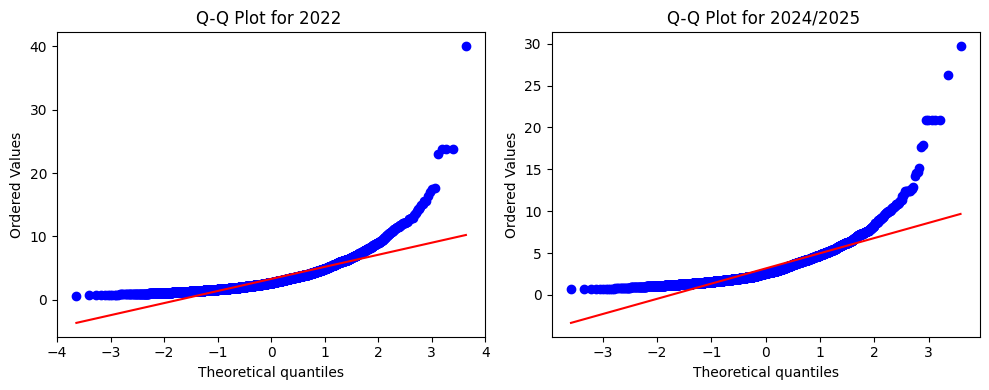

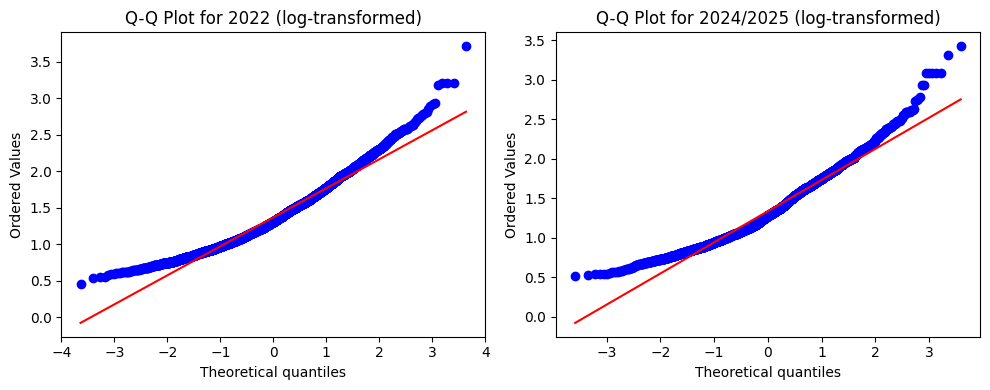

In [29]:
# Q-Q Plot for each group (excluding zeros)
plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = df_filtered[df_filtered["group"] == group]["chatgpt_word_ratio"]
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {group} ")
plt.tight_layout()
plt.show()

## Log-transformed
# Q-Q Plot for each group (excluding zeros)
plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = df_filtered[df_filtered["group"] == group]["log_chatgpt_ratio"]
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {group} (log-transformed)")
plt.tight_layout()
plt.show()

### BoxPlot

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_9811/2559901147.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


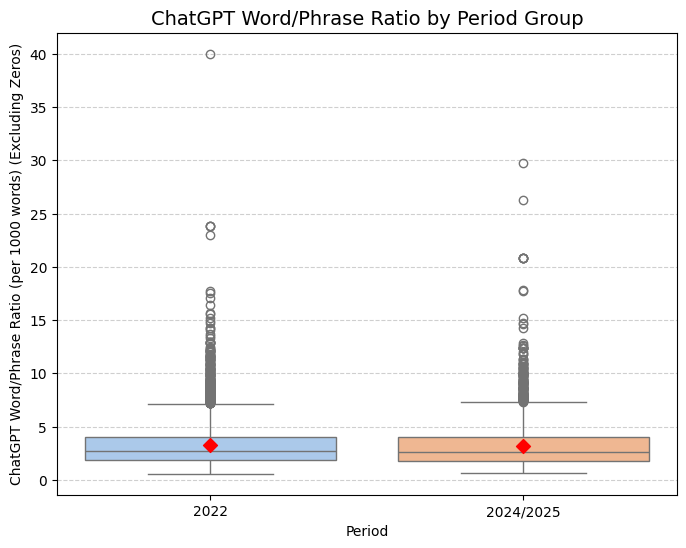

Boxplot saved to: plot_outputs/chatgpt_word_ratio_boxplot_by_period_group_nonzero.png


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_9811/2559901147.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


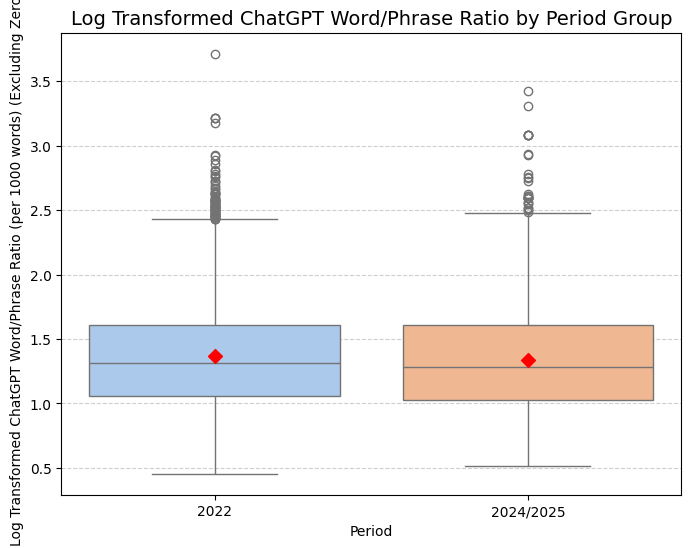

Boxplot saved to: plot_outputs/log_chatgpt_word_ratio_boxplot_by_period_group_nonzero.png


In [30]:
# Plot setup
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_filtered,
    x='group',
    y='chatgpt_word_ratio',
    order=["2022", "2024/2025"],
    palette='pastel'
)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = df_filtered.groupby("group")["chatgpt_word_ratio"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, marker='D', s=50)

# Axis and title
plt.title("ChatGPT Word/Phrase Ratio by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("ChatGPT Word/Phrase Ratio (per 1000 words) (Excluding Zeros)")
#plt.ylim(-100, 120) #Adjust if needed

# Save and show
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)
output_path = os.path.join(output_plot_dir, "chatgpt_word_ratio_boxplot_by_period_group_nonzero.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Boxplot saved to: {output_path}")

## Same but with Log
# Plot setup
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_filtered,
    x='group',
    y='log_chatgpt_ratio',
    order=["2022", "2024/2025"],
    palette='pastel'
)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = df_filtered.groupby("group")["log_chatgpt_ratio"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, marker='D', s=50)

# Axis and title
plt.title("Log Transformed ChatGPT Word/Phrase Ratio by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("Log Transformed ChatGPT Word/Phrase Ratio (per 1000 words) (Excluding Zeros)")
#plt.ylim(-100, 120) #Adjust if needed

# Save and show
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)
output_path = os.path.join(output_plot_dir, "log_chatgpt_word_ratio_boxplot_by_period_group_nonzero.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Boxplot saved to: {output_path}")


### Levene's, Welch's T-test, and Mann-Whitney U, Cohen's d

In [36]:
### Using only Log data, because the "raw" data violated the assumption of normality

# Prepare groups
group_2022 = df_filtered[df_filtered["group"] == "2022"]
group_recent = df_filtered[df_filtered["group"] == "2024/2025"]

# For Welch's and Mann-Whitney: only compare intensity where ratio > 0
log_intensity_2022 = group_2022[group_2022["log_chatgpt_ratio"] > 0]["log_chatgpt_ratio"]
log_intensity_recent = group_recent[group_recent["log_chatgpt_ratio"] > 0]["log_chatgpt_ratio"]

# Levene’s Test (equality of variance)
lev_stat, lev_p = levene(log_intensity_2022, log_intensity_recent)
print(f"Levene's test: W = {lev_stat:.3f}, p = {lev_p:.4f} (log-transformed)")

# Welch’s T-test
t_stat, t_p = ttest_ind(log_intensity_recent, log_intensity_2022, equal_var=False)
print(f"Welch's t-test: t = {t_stat:.3f}, p = {t_p:.4f} (log-transformed)")

# Mann-Whitney U Test
u_stat, u_p = mannwhitneyu(log_intensity_recent, log_intensity_2022, alternative='two-sided')
print(f"Mann-Whitney U test: U = {u_stat}, p = {u_p:.4f} (log-transformed)")

# Cohen's d 
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled_sd = np.sqrt(((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2))
    return diff / pooled_sd

d = cohens_d(log_intensity_recent, log_intensity_2022)
print(f"Cohen's d: {d:.3f} (log-transformed)")

Levene's test: W = 0.184, p = 0.6682 (log-transformed)
Welch's t-test: t = -3.986, p = 0.0001 (log-transformed)
Mann-Whitney U test: U = 9966105.5, p = 0.0001 (log-transformed)
Cohen's d: -0.084 (log-transformed)


### Z-test (non-log transformed data only)

In [35]:
# Prepare groups
raw_group_2022 = df[df["group"] == "2022"]
raw_group_recent = df[df["group"] == "2024/2025"]

# Proportion Z-Test
successes = [
    (raw_group_2022["chatgpt_word_count"] > 0).sum(),
    (raw_group_recent["chatgpt_word_count"] > 0).sum()
]
nobs = [len(raw_group_2022), len(raw_group_recent)]

z_stat, z_p = proportions_ztest(successes, nobs)
print(f"Proportion Z-test: z = {z_stat:.3f}, p = {z_p:.4f}")

Proportion Z-test: z = -10.279, p = 0.0000


### Proportion Barplot

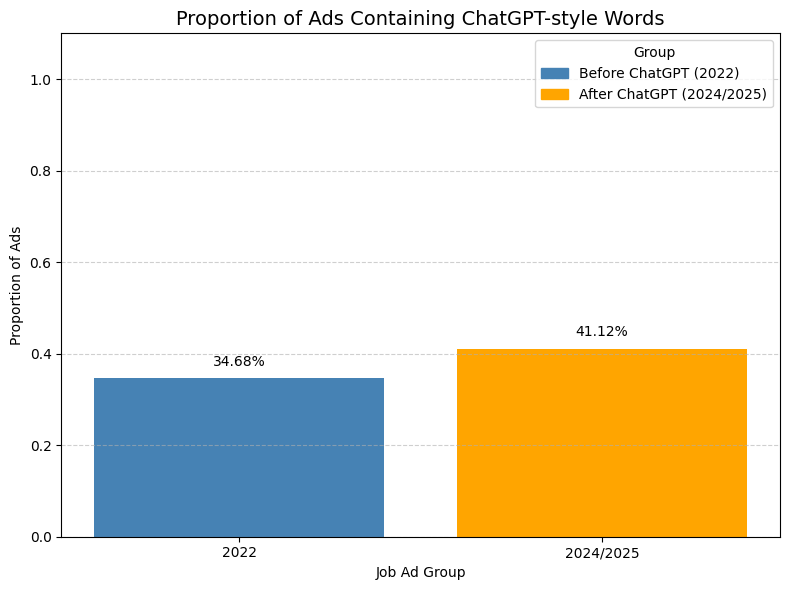

Plot saved to: plot_outputs/proportion_gpt_ads_grouped.png


In [38]:
# Bar Plot: Proportion of ads using GPT-style words
# Create output directory for consistency
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Bar Plot: Proportion of ads using GPT-style words
df["has_gpt_word"] = df["chatgpt_word_count"] > 0
prop_df = df.groupby("group")["has_gpt_word"].mean().reset_index()

# Define colors based on group
bar_colors = ["steelblue" if g == "2022" else "orange" for g in prop_df["group"]]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(prop_df["group"], prop_df["has_gpt_word"], color=bar_colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2%}", ha='center', va='bottom', fontsize=10)

# Labels and formatting
ax.set_title("Proportion of Ads Containing ChatGPT-style Words", fontsize=14)
ax.set_xlabel("Job Ad Group")
ax.set_ylabel("Proportion of Ads")
ax.set_ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Legend
legend_handles = [
    Patch(color="steelblue", label="Before ChatGPT (2022)"),
    Patch(color="orange", label="After ChatGPT (2024/2025)")
]
ax.legend(handles=legend_handles, title="Group")

# Save and show plot
output_path = os.path.join(output_plot_dir, "proportion_gpt_ads_grouped.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to: {output_path}")